In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

train = pd.read_csv("data/processed/train_features.csv")
test = pd.read_csv("data/processed/test_features.csv")

X_train, y_train = train.drop(columns=['target']), train['target']
X_test, y_test = test.drop(columns=['target']), test['target']

model = joblib.load("src/models/artifacts/pd_model_xgb.joblib")

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = XGBClassifier(**model.get_params())

roc_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring='roc_auc')
pr_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring='average_precision')

print(f"ROC-AUC across folds: {np.round(roc_scores, 4)}")
print(f"mean={roc_scores.mean():.4f}  std={roc_scores.std():.4f}")
print(f"PR-AUC across folds:  {np.round(pr_scores, 4)}")
print(f"mean={pr_scores.mean():.4f}  std={pr_scores.std():.4f}")

ROC-AUC across folds: [0.7295 0.7304 0.7319 0.7296 0.7286]
mean=0.7300  std=0.0011
PR-AUC across folds:  [0.402  0.4052 0.4063 0.4024 0.4021]
mean=0.4036  std=0.0018


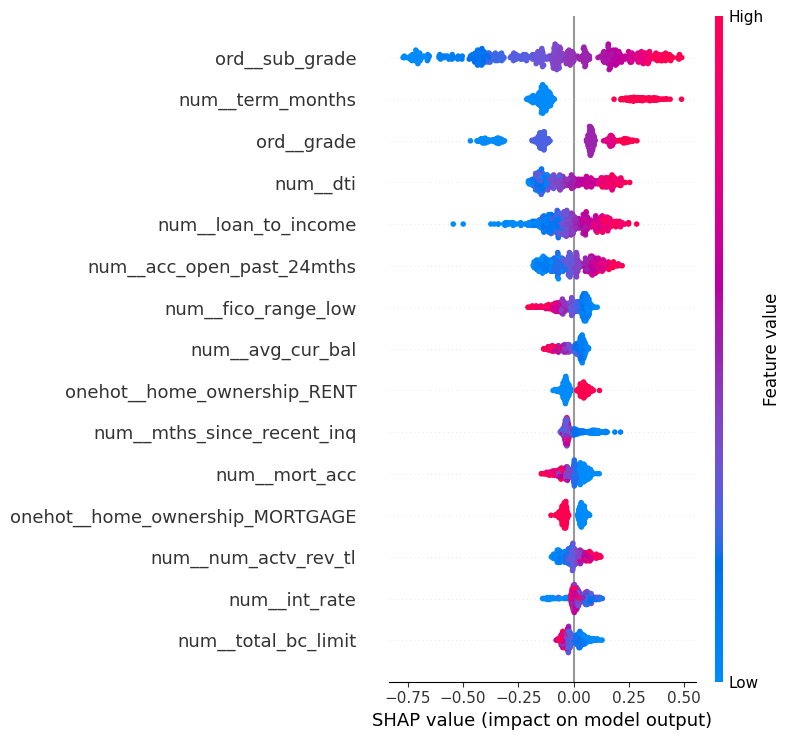

In [3]:
explainer = shap.TreeExplainer(model)
sample_size = min(500, len(X_test))
X_shap = X_test.sample(sample_size, random_state=42)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
plt.tight_layout()
plt.show()

Predicted PD for this applicant: 20.93%


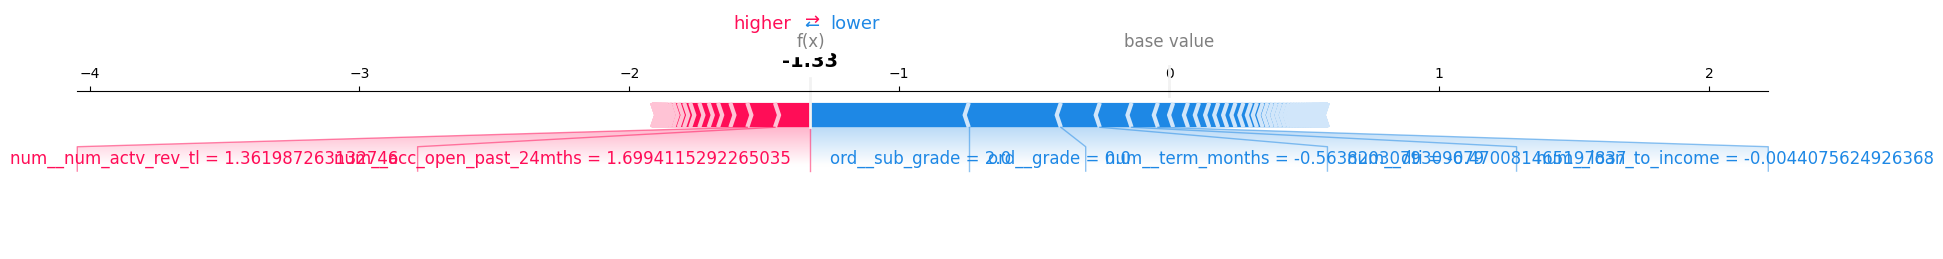

In [4]:
applicant_idx = 0
applicant = X_shap.iloc[[applicant_idx]]

applicant_shap = explainer.shap_values(applicant)
predicted_pd = model.predict_proba(applicant)[0, 1]

print(f"Predicted PD for this applicant: {predicted_pd:.2%}")

shap.force_plot(
    explainer.expected_value, applicant_shap[0], applicant,
    matplotlib=True, show=False,
)
plt.tight_layout()
plt.show()

In [5]:
contrib = pd.Series(applicant_shap[0], index=applicant.columns).sort_values(key=abs, ascending=False)
contrib.head(10).to_frame('shap_value')

,shap_value
ord__sub_grade,-0.586425
ord__grade,-0.341106
num__term_months,-0.144304
num__acc_open_past_24mths,0.131750
num__dti,-0.117726
num__num_actv_rev_tl,0.102410
num__loan_to_income,-0.097607
num__int_rate,0.062810
num__mort_acc,-0.056502
num__emp_length_years,-0.054949


In [6]:
def population_stability_index(expected, actual, buckets=10):
    expected, actual = pd.Series(expected).dropna(), pd.Series(actual).dropna()
    breakpoints = np.linspace(0, 100, buckets + 1)
    bucket_edges = np.percentile(expected, breakpoints)
    bucket_edges[0], bucket_edges[-1] = -np.inf, np.inf
    bucket_edges = np.unique(bucket_edges)

    expected_pct = pd.cut(expected, bucket_edges).value_counts(normalize=True).sort_index()
    actual_pct = pd.cut(actual, bucket_edges).value_counts(normalize=True).sort_index()

    expected_pct = expected_pct.replace(0, 1e-4)
    actual_pct = actual_pct.reindex(expected_pct.index, fill_value=1e-4).replace(0, 1e-4)

    return ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()

numeric_cols = [c for c in X_train.columns if X_train[c].nunique() > 10][:15]
psi_results = pd.Series(
    {col: population_stability_index(X_train[col], X_test[col]) for col in numeric_cols}
).sort_values(ascending=False)

psi_results.to_frame('PSI')

,PSI
num__annual_inc,1.454201e-04
num__fico_range_high,5.862038e-05
num__fico_range_low,5.862038e-05
num__open_acc,5.499568e-05
num__int_rate,5.114299e-05
num__mths_since_last_delinq,3.479023e-05
num__revol_bal,2.848353e-05
num__dti,2.323226e-05
num__funded_amnt_inv,2.210245e-05
num__loan_amnt,1.685152e-05


In [7]:
flagged = psi_results[psi_results > 0.1]
if len(flagged):
    print(f"{len(flagged)} feature(s) show moderate-or-greater drift between train and test:")
    print(flagged)
else:
    print("No features show meaningful train/test drift (PSI < 0.1 for all checked features).")

No features show meaningful train/test drift (PSI < 0.1 for all checked features).


In [9]:
import os
os.makedirs("src/monitoring/artifacts", exist_ok=True)

joblib.dump(explainer, "src/explainability/shap_explainer.joblib") if os.path.isdir("../src/explainability") else None
psi_results.to_csv("src/monitoring/artifacts/train_test_psi_baseline.csv")

validation_summary = {
    'cv_roc_auc_mean': roc_scores.mean(), 'cv_roc_auc_std': roc_scores.std(),
    'cv_pr_auc_mean': pr_scores.mean(), 'cv_pr_auc_std': pr_scores.std(),
}
joblib.dump(validation_summary, "src/monitoring/artifacts/validation_summary.joblib")

['src/monitoring/artifacts/validation_summary.joblib']